# Plot Neutron $G_E^n$ and $G_M^n$ Fitting Results 
Plot neutron form factor vs. Q^2max for fits  with stat errors.

In [53]:
##Import and Definition
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})


import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=16)

Lambda2 = 0.71
GE0 = 0.0
GM0 = -1.91304272
bnd = '5'
fitdata = 'world'

## $G_E^n$

### Load $G_E^n$ Fitting Results

In [54]:
##Load Neutron-GEn Sum-Rules Results{{{
##################################################
## General GEn parameters
Q2plot = 1001.0
kmax = 10
Q2str = '1000' # <4 for GEn, <10 for GMn
mod = 'GEn'
t0mod = 't0fix7'
folder = './mar30_world_norm_bound5/z'+str(kmax) # folder containing central fits

filename=folder+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'

# Extract results from text file for non-sum rule fits.
Q2e_sr = []
Ze_sr = []
GE_fit_sr = []
GE_pos_sr = []
GE_neg_sr = []
GErat_fit_sr = []
GErat_pos_sr = []
GErat_neg_sr = []
GED_sr=[]

redchi2_GE_sr=0.0
chi2_GE_sr=0.0
rad_GE_sr=0.0
drad_GE_sr = 0.0
ndof_GE_sr = 0
chi2_Ng_GE_sr=0.0
chi2_gn_GE_sr=0.0
nmax_GE_sr = 0

fitlines2 = open(filename, 'r').readlines()
[Q2max_gen_sr, tcut_gen_sr, t0_gen_sr] = [float(fitlines2[2006].split()[i]) for i in range(0,3)]

for i in range(1,2001):
    values = fitlines2[i].split()
    values = np.array(values, dtype=float)
    if values[0] > Q2plot:
        break
    Q2e_sr.append(values[0])
    Ze_sr.append(values[1])
    Gdip = 1./(1.+values[0]/0.71)**2
    GED_sr.append(Gdip)
    GE_fit_sr.append(values[2])
    GE_pos_sr.append((values[2]+abs(values[3])))
    GE_neg_sr.append((values[2]-abs(values[3])))
    GErat_fit_sr.append(values[2]/Gdip)
    GErat_pos_sr.append((values[2]+abs(values[3]))/Gdip)
    GErat_neg_sr.append((values[2]-abs(values[3]))/Gdip)

values = fitlines2[2008].split()
redchi2_GE_sr=float(values[0])
chi2_GE_sr=float(values[1])
chi2_Ng_GE_sr=float(values[2])
chi2_gn_GE_sr=float(values[3])

rad_GE_sr=float(values[4])
drad_GE_sr = float(values[5])
ndof_GE_sr = float(values[6])
kmax_GE_sr = float(values[7])
num_GE_sr = float(values[8])
kGN_GE_sr = float(values[9])
kNorm_GE_sr = float(values[10])
chi2_GE_fake_sr=float(values[11])

drad_GE_sr = abs(drad_GE_sr)

tot_chi2_GE_sr = chi2_GE_sr+chi2_gn_GE_sr+chi2_Ng_GE_sr
ndof_GE_sr = ndof_GE_sr - kNorm_GE_sr

Q2e_sr = np.array(Q2e_sr, dtype=float)
Ze_sr = np.array(Ze_sr, dtype=float)
GE_fit_sr = np.array(GE_fit_sr, dtype=float)
GE_pos_sr = np.array(GE_pos_sr, dtype=float)
GE_neg_sr = np.array(GE_neg_sr, dtype=float)
GErat_fit_sr = np.array(GErat_fit_sr, dtype=float)
GErat_pos_sr = np.array(GErat_pos_sr, dtype=float)
GErat_neg_sr = np.array(GErat_neg_sr, dtype=float)
GED_sr = np.array(GED_sr, dtype=float)
#}}}

if os.path.isfile(filename):
    print 'file exist', filename
else:
    rad_GE_sr = 0.0
    drad_GE_sr = 0.0

file exist ./mar30_world_norm_bound5/z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GEn.dat


In [55]:
##Load Neutron-GEn KMAX=20 Results{{{
##################################################
folder1 = './mar30_world_norm_bound5/z'+str(20) # folder containing central fits
#filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(10)+'_gb'+bnd+'_'+t0mod+'_'+mod+'_noRE.dat'
#filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(10)+'_gb'+bnd+'_'+'t0opt'+'_'+mod+'.dat'
#filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+'1'+'_z'+str(10)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'
filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(20)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'

# Extract results from text file for non-sum rule fits.
Q2e = []
Ze = []
GE_fit = []
GE_pos = []
GE_neg = []
GErat_fit = []
GErat_pos = []
GErat_neg = []
GED=[]

redchi2_GE=0.0
chi2_GE=0.0
rad_GE=0.0
drad_GE = 0.0
ndof_GE = 0
chi2_Ng_GE=0.0
chi2_gn_GE=0.0
nmax_GE = 0

fitlines2 = open(filename, 'r').readlines()
[Q2max_gen, tcut_gen, t0_gen] = [float(fitlines2[2006].split()[i]) for i in range(0,3)]

for i in range(1,2001):
    values = fitlines2[i].split()
    values = np.array(values, dtype=float)
    if values[0] > Q2plot:
        break
    Q2e.append(values[0])
    Ze.append(values[1])
    Gdip = 1./(1.+values[0]/0.71)**2
    GED.append(Gdip)
    GE_fit.append(values[2])
    GE_pos.append((values[2]+abs(values[3])))
    GE_neg.append((values[2]-abs(values[3])))
    GErat_fit.append(values[2]/Gdip)
    GErat_pos.append((values[2]+abs(values[3]))/Gdip)
    GErat_neg.append((values[2]-abs(values[3]))/Gdip)

values = fitlines2[2008].split()
redchi2_GE=float(values[0])
chi2_GE=float(values[1])
chi2_Ng_GE=float(values[2])
chi2_gn_GE=float(values[3])

rad_GE=float(values[4])
drad_GE = float(values[5])
ndof_GE = float(values[6])
kmax_GE = float(values[7])
num_GE = float(values[8])
kGN_GE = float(values[9])
kNorm_GE = float(values[10])
chi2_GE_fake=float(values[11])

drad_GE = abs(drad_GE)

tot_chi2_GE = chi2_GE+chi2_gn_GE+chi2_Ng_GE
ndof_GE = ndof_GE - kNorm_GE

Q2e = np.array(Q2e, dtype=float)
Ze = np.array(Ze, dtype=float)
GE_fit = np.array(GE_fit, dtype=float)
GE_pos = np.array(GE_pos, dtype=float)
GE_neg = np.array(GE_neg, dtype=float)
GErat_fit = np.array(GErat_fit, dtype=float)
GErat_pos = np.array(GErat_pos, dtype=float)
GErat_neg = np.array(GErat_neg, dtype=float)
GED = np.array(GED, dtype=float)
#}}}

if os.path.isfile(filename):
    print 'file exist', filename
else:
    rad_GE = 0.0
    drad_GE = 0.0

file exist ./mar30_world_norm_bound5/z20/out_world_sumrules_leastsq_Q21000_z20_gb5_t0fix7_GEn.dat


### Load $G_E^n$ Data Points

In [56]:
## Load GEn Data
#########################{{{
def loadGEn(Q2_max, t0, tcut):
    Q2n=[]
    Zn=[]
    GEn=[]
    dGEn=[]
    GEn_rat=[]
    dGEn_rat=[]
        
    fitlines = open('../data/GLOBFIT16_gen_sep20.out', 'r').readlines()
    #fitlines = open('../data/DOE13_gen.out', 'r').readlines()
    for i in range(1,len(fitlines)):
        values = fitlines[i].split()
        values = np.array(values, dtype=float)
        try:#eliminates descriptions in 1st line of file
            Q2test=values[0]
        except:
            continue

        if Q2test>Q2_max:
            continue

        Q2n.append(values[0])
        Gdip = 1./(1.+values[0]/0.71)**2
        GEn.append(values[1])
        dGEn.append(values[2])
        GEn_rat.append(values[1]/Gdip)
        dGEn_rat.append(values[2]/Gdip)

        Q2 = float(values[0])
        z = (sqrt(1+Q2/tcut) - sqrt(1-t0/tcut))/(sqrt(1+Q2/tcut) + sqrt(1-t0/tcut))
        Zn.append(z)

    return Q2n,z, GEn, dGEn,GEn_rat,dGEn_rat
#######################
##Read GE/GD, GM/nuGD, and GE/GM from John's 2007 paper
Q2e_data_sr, Ze_data_sr, GE_data_sr, dGE_data_sr,GErat_data_sr,dGErat_data_sr =loadGEn(Q2plot, t0_gen_sr, tcut_gen_sr)

Q2e_data_sr=np.array(Q2e_data_sr, dtype=float)
Ze_data_sr=np.array(Ze_data_sr, dtype=float)
GE_data_sr=np.array(GE_data_sr, dtype=float)
dGE_data_sr=np.array(dGE_data_sr, dtype=float)
GErat_data_sr=np.array(GErat_data_sr, dtype=float)
dGErat_data_sr=np.array(dGErat_data_sr, dtype=float)
#}}}

### Plot $G_E^n$

In [57]:
## Plotting Range
ymin_GE = -0.3 #np.minimum(np.amin(GM_fit_sr),np.amin(GM_fit))*0.75
ymax_GE = 1.
xmax_GE = 10.
xmin_GE = 0.004

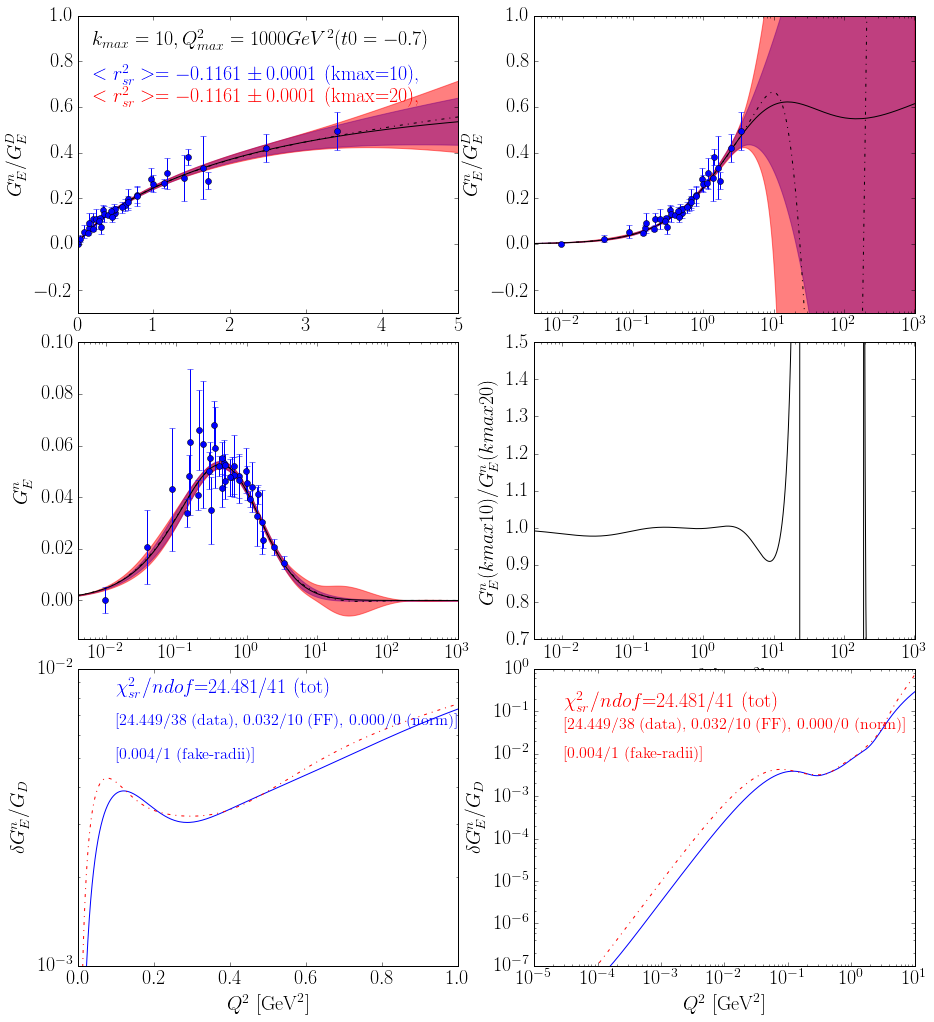

In [58]:
## Plot GEn##########{{{
f1, ax = plt.subplots(3, 2, sharex=False, figsize=(15,15))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)
plt.grid()

#######  Subplot for GErat
axGE1=ax[0,0]
axGE1.plot(Q2e_sr, GErat_fit_sr, 'k-', color='black',  label='GEfit')
axGE1.fill_between(Q2e_sr, GErat_neg_sr, GErat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGE1.plot(Q2e, GErat_fit, 'k-.', color='black',  label='GEfit')
axGE1.fill_between(Q2e, GErat_neg, GErat_pos, edgecolor='r',facecolor='r',alpha=0.5)

axGE1.errorbar(Q2e_data_sr, GErat_data_sr, yerr=dGErat_data_sr, fmt='o')

axGE1.set_xlim(xmin_GE, 5)
axGE1.set_ylabel('$G_E^n/G_E^D$') # label, y-axis
axGE1.set_ylim(ymin_GE, ymax_GE)
#axGE1.yaxis.set_major_locator(MultipleLocator((ymax_GE-ymin_GE)/5.0))
#axGE1.yaxis.set_minor_locator(MultipleLocator((ymax_GE-ymin_GE)/10.0))

#######  Subplot for GErat
axGE3=ax[0,1]
axGE3.plot(Q2e_sr, GErat_fit_sr, 'k-', color='black',  label='GEfit')
axGE3.fill_between(Q2e_sr, GErat_neg_sr, GErat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGE3.plot(Q2e, GErat_fit, 'k-.', color='black',  label='GEfit')
axGE3.fill_between(Q2e, GErat_neg, GErat_pos, edgecolor='r',facecolor='r',alpha=0.5)

axGE3.errorbar(Q2e_data_sr, GErat_data_sr, yerr=dGErat_data_sr, fmt='o')

axGE3.set_xscale('log')
axGE3.set_xlim(xmin_GE, 1005.)
axGE3.set_ylabel('$G_E^n/G_E^D$') # label, y-axis
axGE3.set_ylim(ymin_GE, ymax_GE)

#######  Subplot for GE.
axGE4=ax[1,0]
axGE4.plot(Q2e_sr, GE_fit_sr, 'k-', color='black',  label='GEfit')
axGE4.fill_between(Q2e_sr, GE_neg_sr, GE_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGE4.plot(Q2e, GE_fit, 'k-.', color='black',  label='GEfit')
axGE4.fill_between(Q2e, GE_neg, GE_pos, edgecolor='r',facecolor='r',alpha=0.5)

axGE4.errorbar(Q2e_data_sr, GE_data_sr, yerr=dGE_data_sr, fmt='o')

axGE4.set_xscale('log')
axGE4.set_xlim(xmin_GE, 1005.)
axGE4.set_ylabel('$G_E^n$') # label, y-axis
axGE4.set_ylim(-0.015, 0.1)

#######  Subplot for GE.
######  Subplot for GErat
axGE31=ax[1,1]
#axGE31.plot(Q2e_sr, GErat_fit_sr, 'k-', color='black',  label='GEfit')
#axGE31.fill_between(Q2e_sr, GErat_neg_sr, GErat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

#axGE31.plot(Q2e, GErat_fit, 'k-.', color='black',  label='GEfit')
#axGE31.fill_between(Q2e, GErat_neg, GErat_pos, edgecolor='r',facecolor='r',alpha=0.5)

#axGE31.errorbar(Q2e_data_sr, GErat_data_sr, yerr=dGErat_data_sr, fmt='o')

axGE31.plot(Q2e_sr, GErat_fit_sr/GErat_fit, 'k-', color='black',  label='GEfit')


axGE31.set_xscale('log')
axGE31.set_xlim(xmin_GE, 1005.)
axGE31.set_ylabel('$G_E^n(kmax10)/G_E^n(kmax20)$') # label, y-axis
axGE31.set_ylim(0.7, 1.5)
axGE31.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

## Subplot for deltaGE/GD
axGE5=ax[2,0]
axGE5.plot(Q2e_sr, (GE_pos_sr - GE_fit_sr)/GED_sr, 'k-', color='b',  label='kmax=10')
axGE5.plot(Q2e, (GE_pos - GE_fit)/GED, 'k-.', color='r',  label='kmax=20')

#axGE5.set_ylim(1e-3, 3.0)
axGE5.set_xlim(0.0, 1.0)
axGE5.set_yscale('log')
axGE5.set_ylim(1e-3, 1e-2)
plt.grid()

axGE6=ax[2,1]
axGE6.plot(Q2e_sr, (GE_pos_sr - GE_fit_sr)/GED_sr, 'k-', color='b',  label='kmax=10')
axGE6.plot(Q2e, (GE_pos - GE_fit)/GED, 'k-.', color='r',  label='kmax=20')

axGE6.set_xscale('log')
axGE6.set_yscale('log')
axGE6.set_ylim(1e-7, 1.0)
axGE6.set_xlim(1e-5, 1e1)

axGE5.set_ylabel('$\delta G_E^n / G_D$') # label, y-axis
axGE6.set_ylabel('$\delta G_E^n / G_D$') # label, y-axis
#######  x-axis labelling, etc.
axGE5.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis
axGE6.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

#######  x-axis labelling, etc.
#axGE3.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

axGE1.text(0.2, 0.85, r'$k_{max}=%d, Q^2_{max}=%s GeV^2 (t0=-0.7)$'%(kmax,Q2str))
axGE1.text(0.2, 0.7, r'$<r^{2}_{sr}>=%5.4f\pm %5.4f$ (kmax=10),'%( rad_GE_sr, drad_GE_sr), color='blue')
axGE1.text(0.2, 0.6, r'$<r^{2}_{sr}>=%5.4f\pm %5.4f$ (kmax=20),'%( rad_GE, drad_GE), color='r')

axGE5.text(1e-1, 8e-3, r'$\chi^{2}_{sr}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GE_sr, ndof_GE_sr), color='blue')
axGE5.text(1e-1, 6.5e-3, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
         %(chi2_GE_sr, num_GE_sr, chi2_gn_GE_sr, kmax_GE_sr,chi2_Ng_GE_sr, kNorm_GE_sr), 
          fontproperties=font_prop, color='blue')
axGE5.text(1e-1, 5e-3, r'[%5.3f/1 (fake-radii)]'
         %(chi2_GE_fake_sr), 
          fontproperties=font_prop, color='blue')

axGE6.text(3e-5, 1e-1, r'$\chi^{2}_{sr}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GE_sr, ndof_GE_sr), color='r')
axGE6.text(3e-5, 4e-2, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
         %(chi2_GE_sr, num_GE_sr, chi2_gn_GE_sr, kmax_GE_sr,chi2_Ng_GE_sr, kNorm_GE_sr), 
          fontproperties=font_prop, color='r')
axGE6.text(3e-5, 8e-3, r'[%5.3f/1 (fake-radii)]'
         %(chi2_GE_fake_sr), 
          fontproperties=font_prop, color='r')



# plt.show()
#plotname=filename.replace('.dat','.png')
plotname='GEn_Com_kmax10_kmax20.png'
plt.savefig(plotname,bbox_inches='tight')
plotname=plotname.replace('.png','.pdf')
plt.savefig(plotname,bbox_inches='tight')
#}}}

## $G_M^n$

### Load $G_M^n$ Fitting Results

In [59]:
##General GMn parameters .
Q2plot = 1001
Q2str = '1000' # <4 for GEn, <10 for GMn

mod = 'GMn'
folder = './mar30_world_norm_bound5/z'+str(kmax) # folder containing central fits

In [60]:
### Load Neutron-GMn Sum-Rules Results{{{
##################################################
filename=folder+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'

# Extract results from text file for non-sum rule fits.
Q2m_sr = []
Zm_sr = []
GM_fit_sr = []
GM_pos_sr = []
GM_neg_sr = []
GMrat_fit_sr = []
GMrat_pos_sr = []
GMrat_neg_sr = []
GMD_sr=[]

redchi2_GM_sr=0.0
chi2_GM_sr=0.0
rad_GM_sr=0.0
drad_GM_sr = 0.0
ndof_GM_sr = 0
chi2_Ng_GM_sr=0.0
chi2_gn_GM_sr=0.0
nmax_GM_sr = 0

fitlines4 = open(filename, 'r').readlines()
[Q2max_gmn_sr, tcut_gmn_sr, t0_gmn_sr] = [float(fitlines4[2006].split()[i]) for i in range(0,3)]

for i in range(1,2001):
    values = fitlines4[i].split()
    values = np.array(values, dtype=float)
    if values[0] > Q2plot:
        break
    Q2m_sr.append(values[0])
    Zm_sr.append(values[1])
    Gdip = 1./(1.+values[0]/0.71)**2
    GMD_sr.append(GM0*Gdip)
    GM_fit_sr.append(values[2])
    GM_pos_sr.append((values[2]+abs(values[3])))
    GM_neg_sr.append((values[2]-abs(values[3])))
    GMrat_fit_sr.append(values[2]/(GM0*Gdip))
    GMrat_pos_sr.append((values[2]+abs(values[3]))/(GM0*Gdip))
    GMrat_neg_sr.append((values[2]-abs(values[3]))/(GM0*Gdip))

values = fitlines4[2008].split()
redchi2_GM_sr=float(values[0])
chi2_GM_sr=float(values[1])
chi2_Ng_GM_sr=float(values[2])
chi2_gn_GM_sr=float(values[3])

rad_GM_sr=float(values[4])
drad_GM_sr = float(values[5])
ndof_GM_sr = float(values[6])
kmax_GM_sr = float(values[7])
num_GM_sr = float(values[8])
kGN_GM_sr = float(values[9])
kNorm_GM_sr = float(values[10])
chi2_GM_fake_sr=float(values[11])

drad_GM_sr = abs(drad_GM_sr)

tot_chi2_GM_sr = chi2_GM_sr+chi2_gn_GM_sr+chi2_Ng_GM_sr
ndof_GM_sr = ndof_GM_sr - kNorm_GM_sr

Q2m_sr = np.array(Q2m_sr, dtype=float)
Zm_sr = np.array(Zm_sr, dtype=float)
GM_fit_sr = np.array(GM_fit_sr, dtype=float)
GM_pos_sr = np.array(GM_pos_sr, dtype=float)
GM_neg_sr = np.array(GM_neg_sr, dtype=float)
GMrat_fit_sr = np.array(GMrat_fit_sr, dtype=float)
GMrat_pos_sr = np.array(GMrat_pos_sr, dtype=float)
GMrat_neg_sr = np.array(GMrat_neg_sr, dtype=float)
GMD_sr = np.array(GMD_sr, dtype=float)
#for i in range(len(Q2m)):
#    print '---', Q2m[i], GM_fit[i]
#}}}

if os.path.isfile(filename):
    print 'file exist', filename
else:
    rad_GM_sr = 0.0
    drad_GM_sr = 0.0
    
filename1=folder+'/mar30_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'
fitlines00 = open(filename1, 'r').readlines()
Ngn_sr = [float(x) for x in fitlines00[len(fitlines00)-1].lstrip('[').rstrip(']\n').split(',')]

file exist ./mar30_world_norm_bound5/z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GMn.dat


In [61]:
### Load kmax=20 Results{{{
##################################################
folder1 = './mar30_world_norm_bound5/z'+str(20) # folder containing central fits
#filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(10)+'_gb'+bnd+'_'+t0mod+'_'+mod+'_noRM.dat'
#filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(10)+'_gb'+bnd+'_'+'t0opt'+'_'+mod+'.dat'
#filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+'1'+'_z'+str(10)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'
filename=folder1+'/out_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(20)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'

# Extract results from text file for non-sum rule fits.
Q2m = []
Zm = []
GM_fit = []
GM_pos = []
GM_neg = []
GMrat_fit = []
GMrat_pos = []
GMrat_neg = []
GMD=[]

redchi2_GM=0.0
chi2_GM=0.0
rad_GM=0.0
drad_GM = 0.0
ndof_GM = 0
chi2_Ng_GM=0.0
chi2_gn_GM=0.0
nmax_GM = 0

fitlines4 = open(filename, 'r').readlines()
[Q2max_gmn, tcut_gmn, t0_gmn] = [float(fitlines4[2006].split()[i]) for i in range(0,3)]

for i in range(1,2001):
    values = fitlines4[i].split()
    values = np.array(values, dtype=float)
    if values[0] > Q2plot:
        break
    Q2m.append(values[0])
    Zm.append(values[1])
    Gdip = 1./(1.+values[0]/0.71)**2
    GMD.append(GM0*Gdip)
    GM_fit.append(values[2])
    GM_pos.append((values[2]+abs(values[3])))
    GM_neg.append((values[2]-abs(values[3])))
    GMrat_fit.append(values[2]/(GM0*Gdip))
    GMrat_pos.append((values[2]+abs(values[3]))/(GM0*Gdip))
    GMrat_neg.append((values[2]-abs(values[3]))/(GM0*Gdip))

values = fitlines4[2008].split()
redchi2_GM=float(values[0])
chi2_GM=float(values[1])
chi2_Ng_GM=float(values[2])
chi2_gn_GM=float(values[3])

rad_GM=float(values[4])
drad_GM = float(values[5])
ndof_GM = float(values[6])
kmax_GM = float(values[7])
num_GM = float(values[8])
kGN_GM = float(values[9])
kNorm_GM = float(values[10])
chi2_GM_fake=float(values[11])

drad_GM = abs(drad_GM)

tot_chi2_GM = chi2_GM+chi2_gn_GM+chi2_Ng_GM
ndof_GM = ndof_GM - kNorm_GM

Q2m = np.array(Q2m, dtype=float)
Zm = np.array(Zm, dtype=float)
GM_fit = np.array(GM_fit, dtype=float)
GM_pos = np.array(GM_pos, dtype=float)
GM_neg = np.array(GM_neg, dtype=float)
GMrat_fit = np.array(GMrat_fit, dtype=float)
GMrat_pos = np.array(GMrat_pos, dtype=float)
GMrat_neg = np.array(GMrat_neg, dtype=float)
GMD = np.array(GMD, dtype=float)
#for i in range(len(Q2m)):
#    print '---', Q2m[i], GM_fit[i]
#}}}

if os.path.isfile(filename):
    print 'file exist', filename
else:
    rad_GM = 0.0
    drad_GM = 0.0
    
#filename1=folder1+'/mar30_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(10)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'
#filename1=folder1+'/mar30_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(10)+'_gb'+bnd+'_'+'t0opt'+'_'+mod+'.dat'
#filename1=folder1+'/mar30_'+fitdata+'_sumrules_leastsq_Q2'+'1'+'_z'+str(10)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'
filename1=folder1+'/mar30_'+fitdata+'_sumrules_leastsq_Q2'+Q2str+'_z'+str(20)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'

#filename1=folder+'/nR_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'
#filename=folder+'/nHQ_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+t0mod+'_'+mod+'.dat'

fitlines00 = open(filename1, 'r').readlines()
Ngn = [float(x) for x in fitlines00[len(fitlines00)-1].lstrip('[').rstrip(']\n').split(',')]

file exist ./mar30_world_norm_bound5/z20/out_world_sumrules_leastsq_Q21000_z20_gb5_t0fix7_GMn.dat


### Load $G_M^n$ Data Points


In [62]:
## Load GMn Data
#########################{{{
def loadGMn(Q2_max, t0, tcut):
    Q2n=[]
    Zn=[]
    GMn=[]
    dGMn=[]
    GMn_rat=[]
    dGMn_rat=[]
        
    fitlines = open('../data/GLOBFIT16_gmn_sep20.out', 'r').readlines()
    for i in range(1,len(fitlines)):
        values = fitlines[i].split()
        values = np.array(values, dtype=float)
        try:#eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue

        if Q2test>Q2_max:
            continue
        Q2n.append(values[0])
        Gdip = 1./(1.+values[0]/0.71)**2
        GMn_rat.append(values[1])
        dGMn_rat.append(values[2])
        GMn.append(values[1]*GM0*Gdip)
        dGMn.append(values[2]*GM0*Gdip)
    
        Q2 = float(values[0])
        z = (sqrt(1+Q2/tcut) - sqrt(1-t0/tcut))/(sqrt(1+Q2/tcut) + sqrt(1-t0/tcut))
        Zn.append(z)
    
    return Q2n,z,GMn, dGMn, GMn_rat, dGMn_rat
#######################
Q2m_data_sr, Zm_data_sr, GM_data_sr, dGM_data_sr, GMrat_data_sr, dGMrat_data_sr=loadGMn(Q2plot, t0_gmn_sr, tcut_gmn_sr)

Q2m_data_sr=np.array(Q2m_data_sr, dtype=float)
Zm_data_sr=np.array(Zm_data_sr, dtype=float)
GM_data_sr=np.array(GM_data_sr, dtype=float)
dGM_data_sr=np.array(dGM_data_sr, dtype=float)
GMrat_data_sr=np.array(GMrat_data_sr, dtype=float)
dGMrat_data_sr=np.array(dGMrat_data_sr, dtype=float)
#for i in range(len(Q2m_data)):
#    print '---', Q2m_data[i], GM_data[i]
#}}}

### Plot $G_M^n/G_D$ vs. $Q^2$

In [63]:
##Plotting Ranges
ymin_GM = 0.4 #np.minimum(np.amin(GM_fit_sr),np.amin(GM_fit))*0.75
ymax_GM = 1.20
xmax_GM = 11.2

ymin_GM1 = -1.20 #np.minimum(np.amin(GM_fit_sr),np.amin(GM_fit))*0.75
ymax_GM1 = 0.1
xmax_GM1 = 11.2

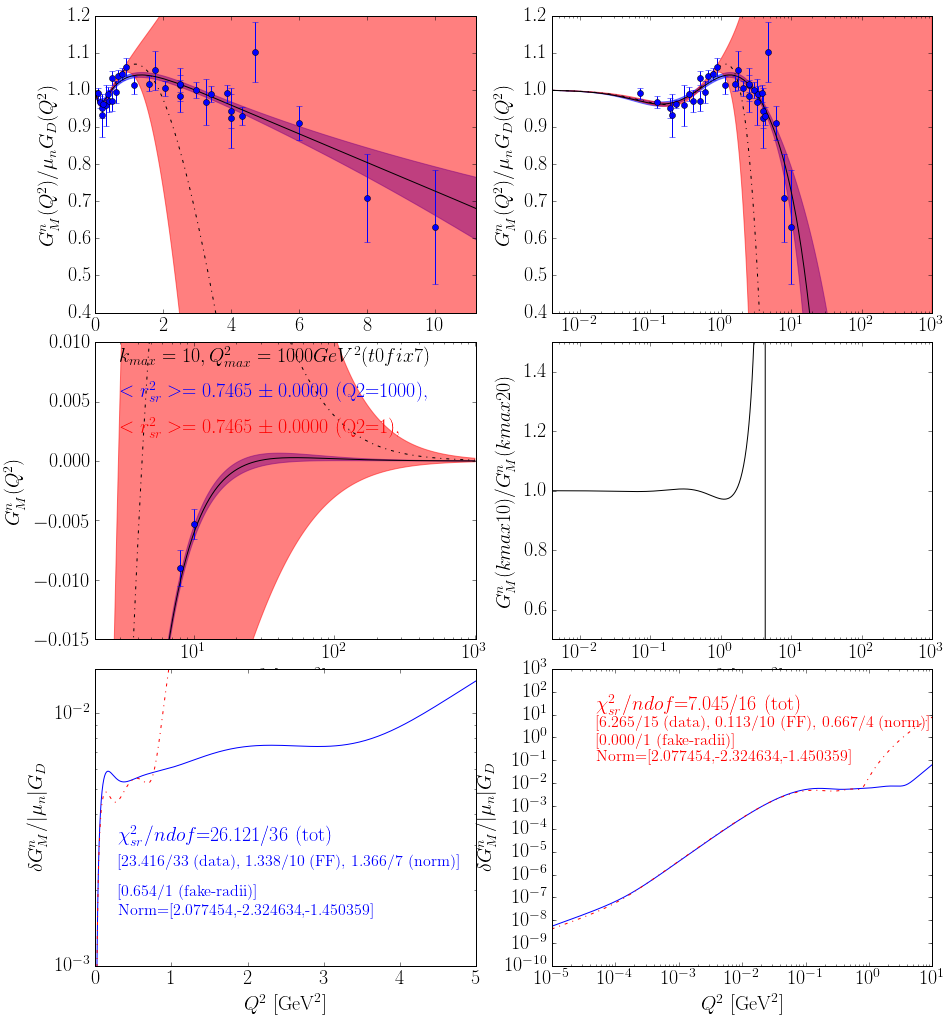

In [52]:
## Plot GMn in log scale##########{{{
f2, ax = plt.subplots(3, 2, sharex=False, figsize=(15,15))
f2.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GM/GD.
axGM1 = ax[0,0]
axGM1.plot(Q2m_sr, GMrat_fit_sr, 'k-', color='black',  label='GMfit')
axGM1.fill_between(Q2m_sr, GMrat_neg_sr, GMrat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGM1.plot(Q2m, GMrat_fit, 'k-.', color='black',  label='GMfit')
axGM1.fill_between(Q2m, GMrat_neg, GMrat_pos, edgecolor='r',facecolor='r',alpha=0.5)

axGM1.errorbar(Q2m_data_sr, GMrat_data_sr, yerr=dGMrat_data_sr, fmt='o')

axGM1.set_xlim(4e-4, xmax_GM)
axGM1.set_ylabel('$G_M^n(Q^2)/\mu_n G_D(Q^2)$') # label, y-axis
axGM1.set_ylim(ymin_GM, ymax_GM)

#######  Subplot for GM.
axGM2 = ax[1,0]
#axGM2.plot(Q2m, GM_fit, 'k--', color='black',  label='GMfit')
#axGM2.fill_between(Q2m, GM_neg, GM_pos, edgecolor='red',facecolor='red',alpha=0.5)

#axGM2.plot(Q2m_sr, GM_fit_sr, 'k-', color='black',  label='GMfit')
#axGM2.fill_between(Q2m_sr, GM_neg_sr, GM_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

#axGM2.errorbar(Q2m_data, GM_data, yerr=dGM_data, fmt='o')

#axGM2.set_xlim(4e-4, xmax_GM1)
#axGM2.set_ylabel('$G_M^n(Q^2)$') # label, y-axis
#axGM2.set_ylim(-2.0, ymax_GM1)

#######  x-axis labelling, etc.
#plt.setp(axGM2.get_xticklabels(), visible=False)
axGM2.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

#######  Subplot for GM/GD.
axGM3 = ax[0,1]
axGM3.plot(Q2m_sr, GMrat_fit_sr, 'k-', color='black',  label='GMfit')
axGM3.fill_between(Q2m_sr, GMrat_neg_sr, GMrat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGM3.plot(Q2m, GMrat_fit, 'k-.', color='black',  label='GMfit')
axGM3.fill_between(Q2m, GMrat_neg, GMrat_pos, edgecolor='r',facecolor='r',alpha=0.5)

axGM3.errorbar(Q2m_data_sr, GMrat_data_sr, yerr=dGMrat_data_sr, fmt='o')

axGM3.set_xscale('log')
axGM3.set_xlim(4e-3, 1015.)
axGM3.set_ylabel('$G_M^n(Q^2)/\mu_n G_D(Q^2)$') # label, y-axis
axGM3.set_ylim(ymin_GM, ymax_GM)

#######  Subplot for GM.
#axGM4 = ax[1,1]
axGM4 = ax[1,0]
axGM4.plot(Q2m_sr, GM_fit_sr, 'k-', color='black',  label='GMfit')
axGM4.fill_between(Q2m_sr, GM_neg_sr, GM_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGM4.plot(Q2m, GM_fit, 'k-.', color='black',  label='GMfit')
axGM4.fill_between(Q2m, GM_neg, GM_pos, edgecolor='r',facecolor='r',alpha=0.5)

axGM4.errorbar(Q2m_data_sr, GM_data_sr, yerr=dGM_data_sr, fmt='o')

axGM4.set_xscale('log')
axGM4.set_xlim(2, 1015.)
axGM4.set_ylabel('$G_M^n(Q^2)$') # label, y-axis
axGM4.set_ylim(-0.015, 0.01)

#######  x-axis labelling, etc.
#plt.setp(axGM4.get_xticklabels(), visible=False)
axGM4.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis


#######  Subplot for GM/GD.
axGM31 = ax[1,1]
#axGM31.plot(Q2m_sr, GMrat_fit_sr, 'k-', color='black',  label='GMfit')
#axGM31.fill_between(Q2m_sr, GMrat_neg_sr, GMrat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

#axGM31.plot(Q2m, GMrat_fit, 'k-.', color='black',  label='GMfit')
#axGM31.fill_between(Q2m, GMrat_neg, GMrat_pos, edgecolor='r',facecolor='r',alpha=0.5)

#axGM31.errorbar(Q2m_data_sr, GMrat_data_sr, yerr=dGMrat_data_sr, fmt='o')
axGM31.plot(Q2m_sr, GM_fit_sr/GM_fit, 'k-', color='black',  label='GMfit')

axGM31.set_xscale('log')
axGM31.set_xlim(4e-3, 1015.)
axGM31.set_ylabel('$G_M^n(kmax10)/G_M^n(kmax20)$') # label, y-axis
axGM31.set_ylim(0.5, 1.5)
axGM31.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

## Subplot for deltaGE/GD
axGM5=ax[2,0]
axGM5.plot(Q2m_sr, (GM_pos_sr - GM_fit_sr)/GMD_sr*-1.0, 'k-', color='b',  label='kmax=10')
axGM5.plot(Q2m, (GM_pos - GM_fit)/GMD*-1.0, 'k-.', color='r',  label='kmax=20')

axGM5.set_ylim(1e-3, 1.5e-2)
axGM5.set_xlim(0.0, 5.0)
axGM5.set_yscale('log')

axGM6=ax[2,1]
axGM6.plot(Q2m_sr, (GM_pos_sr - GM_fit_sr)/GMD_sr*-1.0, 'k-', color='b',  label='kmax=10')
axGM6.plot(Q2m, (GM_pos - GM_fit)/GMD*-1.0, 'k-.', color='r',  label='kmax=20')

axGM6.set_xscale('log')
axGM6.set_yscale('log')
axGM6.set_xlim(1e-5, 1e1)

axGM5.set_ylabel('$\delta G_M^n / |\mu_n|G_D$') # label, y-axis
axGM6.set_ylabel('$\delta G_M^n / |\mu_n|G_D$') # label, y-axis
#######  x-axis labelling, etc.
axGM5.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis
axGM6.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis


####

axGM2.text(3., 0.008, r'$k_{max}=%d, Q^2_{max}=%s GeV^2 (%s)$'%(kmax,Q2str, t0mod))
axGM2.text(3., 0.005, r'$<r^{2}_{sr}>=%5.4f\pm %5.4f$ (Q2=1000),'%(rad_GM_sr, drad_GM_sr), color='blue')
axGM2.text(3., 0.002, r'$<r^{2}_{sr}>=%5.4f\pm %5.4f$ (Q2=1),'%(rad_GM, drad_GM), color='r')

axGM5.text(0.301, 3e-3, r'$\chi^{2}_{sr}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GM_sr, ndof_GM_sr), color='blue')
axGM5.text(0.3005,2.5e-3, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
         %(chi2_GM_sr, num_GM_sr, chi2_gn_GM_sr, kmax_GM_sr,chi2_Ng_GM_sr, kNorm_GM_sr ), 
          fontproperties=font_prop, color='blue')
axGM5.text(0.3005,1.9e-3, r'[%5.3f/1 (fake-radii)]'
         %(chi2_GM_fake_sr),fontproperties=font_prop, color='blue')
axGM5.text(0.3005,1.6e-3, r'Norm=[%f,%f,%f]'
         %(Ngn_sr[0], Ngn_sr[1],Ngn_sr[2]),fontproperties=font_prop, color='blue')

axGM6.text(5e-5, 1e1, r'$\chi^{2}_{sr}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GM, ndof_GM), color='r')
axGM6.text(5e-5,3e0, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
         %(chi2_GM, num_GM, chi2_gn_GM, kmax_GM,chi2_Ng_GM, kNorm_GM ), 
          fontproperties=font_prop, color='r')
axGM6.text(5e-5,5e-1, r'[%5.3f/1 (fake-radii)]'
         %(chi2_GM_fake),fontproperties=font_prop, color='r')
axGM6.text(5e-5,1e-1, r'Norm=[%f,%f,%f]'
         %(Ngn[0], Ngn[1],Ngn[2]),fontproperties=font_prop, color='r')


# plt.show()
plotname='GMn_Com_kmax10_Q21.png'
plt.savefig(plotname,bbox_inches='tight')
plotname=plotname.replace('.png','.pdf')
plt.savefig(plotname,bbox_inches='tight')
#}}}